In [2]:
import numpy as np
import torch
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from scipy.stats import norm

# ----------------------------
# Configuration (WBC)
# ----------------------------
device = torch.device("cpu")  # set 'cuda' if available
print("Device:", device)

# WBC basics
NUM_CLASSES  = 2              # malignant vs benign
INPUT_DIM    = 30             # WBC has 30 numeric features
HIDDEN_0     = 256
HIDDEN_1     = 64
HEAD_DIM     = 1
TARGET_CLASS = 0              # sklearn WBC: 0=malignant, 1=benign

# Training knobs
LR         = 1e-3
EPOCHS     = 1000
CLIP_NORM  = 5.0
MARGIN_M   = 3.0
EPS        = 1e-8
USE_DIAG_COV = False          # True = faster; False = full covariances

# ----------------------------
# Data (WBC)
# ----------------------------
def split_by_class_from_xy(X, y, num_classes=NUM_CLASSES, device=device):
    buckets = []
    for c in range(num_classes):
        Xc = X[y == c].astype(np.float32)
        buckets.append(torch.from_numpy(Xc).to(device))
    return buckets

wbc = load_breast_cancer()
X = wbc.data.astype(np.float32)    # [N, 30]
y = wbc.target.astype(np.int64)    # [N]

# Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# z-score using TRAIN stats only
x_mean = X_train.mean(axis=0, keepdims=True)
x_std  = X_train.std(axis=0, keepdims=True)
x_std  = np.where(x_std < 1e-12, 1.0, x_std)

X_train = (X_train - x_mean) / x_std
X_test  = (X_test  - x_mean) / x_std

train_c = split_by_class_from_xy(X_train, y_train, NUM_CLASSES, device)
test_c  = split_by_class_from_xy(X_test,  y_test,  NUM_CLASSES, device)


Device: cpu


In [3]:
def class_gaussian_stats(buckets, diag_only=False, eps=EPS, device=device):
    """
    Compute per-class mean & covariance (population-style).
    If diag_only=True, stores only diagonal variances for scalability.

    Returns:
      means: [C, D]
      covs:  [C, D, D]  (full) or [C, D] (diag-only)
    """
    means, covs = [], []
    for X in buckets:
        X = X.to(device)
        mu = X.mean(dim=0)           # [D]
        Xc = X - mu
        if diag_only:
            var = (Xc**2).mean(dim=0).clamp_min(eps)  # [D]
            covs.append(var)
        else:
            cov = (Xc.T @ Xc) / Xc.shape[0]           # [D, D]
            cov = cov + eps * torch.eye(Xc.shape[1], device=device)
            covs.append(cov)
        means.append(mu)
    means = torch.stack(means).to(device)
    covs  = torch.stack(covs).to(device)
    return means, covs

# Train-time sufficient statistics (NGN trains only on these)
class_mean, class_cov = class_gaussian_stats(train_c, diag_only=USE_DIAG_COV, device=device)

In [4]:
from scipy import stats
x = X_test[0]
mu1 = class_mean[0].cpu().numpy()
S2 = class_cov[0].cpu().numpy()

mu2 = class_mean[1].cpu().numpy()
S1 = class_cov[1].cpu().numpy()
print("Class 0 logpdf:", stats.multivariate_normal.logpdf(x=x, mean=mu1, cov=S1))
print("Class 1 logpdf:",  stats.multivariate_normal.logpdf(x=x, mean=mu2, cov=S2))

Class 0 logpdf: -193.37868443745936
Class 1 logpdf: -23.049779616210138


In [ ]:
# ----------------------------
# NGN Layers
# ----------------------------
def init_linear_(W, b, gain=0.5):
    """
    Initialization that encourages mask diversity without exploding variances:
      • Orthogonal weights with small gain (or use Xavier/He).
      • Near-zero biases with tiny noise to break symmetry.
    """
    nn.init.orthogonal_(W, gain=gain)
    nn.init.normal_(b, mean=0.0, std=1e-3)

class NGNLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.W = nn.Parameter(torch.empty(out_features, in_features))
        self.b = nn.Parameter(torch.empty(out_features))
        init_linear_(self.W, self.b)

    def forward(self, mu_c, Sigma_c):
        """
        mu_c:    [C, in]
        Sigma_c: [C, in, in] (full) or [C, in] (diag-only)
        returns:
          mu':    [C, out]
          Sigma': [C, out, out] (full) or [C, out] (diag-only)
        """
        C, in_features = mu_c.shape
        out_features = self.W.shape[0]

        # Mean
        mu_out = mu_c @ self.W.t() + self.b  # [C, out]

        # Covariance
        if Sigma_c.dim() == 3:
            # Full: Σ' = W Σ W^T (batched)
            # out[c, o, p] = Σ_{i,j} W[o,i] * Σ[c,i,j] * W[p,j]
            Sigma_out = torch.einsum('oi,cij,pj->cop', self.W, Sigma_c, self.W)
            # (Optional sanity checks in dev)
            # assert Sigma_out.shape == (C, out_features, out_features)
        else:
            # Diagonal: var' = (W^2) @ var_in
            Sigma_out = torch.einsum('oi,ci->co', self.W**2, Sigma_c)
            # assert Sigma_out.shape == (C, out_features)

        return mu_out, Sigma_out

    def inference(self, x):
        return x @ self.W.t() + self.b

class NGNBatchNorm(nn.Module):
    """
    Analytic BN over *classes* (not samples):
      • forward():   normalizes class means; rescales covariances consistently.
      • inference(): applies the same affine transform to data instances.

    This keeps the *analytic* and *inference* paths aligned (same transform).
    """
    def __init__(self, num_features, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.register_buffer("mean_of_mean", torch.zeros(1, num_features))
        self.register_buffer("var_of_mean",  torch.ones(1, num_features))

    def forward(self, mu_c, Sigma_c):
        m = mu_c.mean(dim=0, keepdim=True).detach()
        v = mu_c.var(dim=0, keepdim=True, unbiased=False).detach().clamp_min(self.eps)
        self.mean_of_mean.copy_(m)
        self.var_of_mean.copy_(v)

        mu_norm = (mu_c - m) / torch.sqrt(v)

        if Sigma_c.dim() == 3:
            s = 1.0 / torch.sqrt(v.squeeze(0))  # [F]
            Sigma_norm = Sigma_c * s[None, :, None] * s[None, None, :]
        else:
            Sigma_norm = Sigma_c / v.squeeze(0) # [C, F]
        return mu_norm, Sigma_norm

    def inference(self, x):
        return (x - self.mean_of_mean) / torch.sqrt(self.var_of_mean)
    
# N(m, S), N(f(m), f(S))

# X ~ N(m, S)
# f(X) ~ N(f(m), f(S)) iff f is affine

class NGNMeanMaskReLU(nn.Module):
    """
    Distribution-oriented ReLU (binary gating per neuron):
      • Analytic path: per-class feature ON if mean>0, else OFF.
      • Inference path: per-batch feature ON if batch mean>0, else OFF.
    Within an active region the mapping is affine ⇒ Gaussianity preserved.
    """
    def forward(self, mu_c, Sigma_c):
        mask = (mu_c > 0).float()  # [C, F]
        mu_out = mu_c * mask
        if Sigma_c.dim() == 3:
            Sigma_out = Sigma_c * mask[:, :, None] * mask[:, None, :]
        else:
            Sigma_out = Sigma_c * mask
        return mu_out, Sigma_out

    def inference(self, x):
        m = x.mean(dim=0, keepdim=True)  # [1, F]
        mask = (m > 0).float()
        return x * mask

In [6]:
# ----------------------------
# One-vs-Rest loss (σ-margin) + variance regularization
# ----------------------------

def ovr_soft_sigma_margin(mu, Sigma, target, m=MARGIN_M, temp=5.0, eps=EPS):
    """
    One-vs-Rest Soft σ-Margin Loss
    ------------------------------
    Purpose:
        Encourages the target class Gaussian to be separated from all other class Gaussians
        by at least 'm' standard deviations (σ) — i.e., minimal overlap between distributions.

    Intuition:
        For each impostor class j ≠ target:
            overlap_j = (μ_j + m·σ_j) - (μ_t - m·σ_t)
        If overlap_j < 0 → the two Gaussians are separated by > m·σ margin.
        If overlap_j > 0 → the distributions overlap (penalize proportionally).

        The loss takes a smooth maximum over all violating classes using log-sum-exp:
            loss = log∑_j exp(temp * overlap_j) / temp
        → behaves like a differentiable hinge loss in σ-units.

    Arguments:
        mu     : [C, 1] tensor of per-class means from NGN head.
        Sigma  : [C, 1, 1] (full) or [C, 1] (diag) per-class variances.
        target : int, index of the target ("positive") class for one-vs-rest.
        m      : float, σ-margin — controls required separation in standard deviations.
                  Higher m → stricter non-overlap requirement (harder, more confident boundaries).
        temp   : float, temperature for smoothmax (log-sum-exp).
                  Smaller temp → behaves like hard max (focus on worst violation).
                  Larger temp → softer aggregation (averages over all overlaps).
        eps    : float, small constant for numerical stability.

    Returns:
        scalar differentiable loss (smaller → distributions well separated).

    Example:
        For two well-separated Gaussians:
            μ_target = 3, σ_target = 0.2
            μ_other  = 0, σ_other  = 0.3
            overlap  = (0 + m·0.3) - (3 - m·0.2)
        If m=3 ⇒ overlap = 0.9 - 2.4 = -1.5 → no loss (already separated)
    """
    # Unpack class means and variances
    mu = mu[:, 0]  # [C]
    if Sigma.dim() == 3:
        var = Sigma[:, 0, 0].clamp_min(eps)
    else:
        var = Sigma[:, 0].clamp_min(eps)
    sig = torch.sqrt(var)

    # Compute overlap with each other class
    overlap = (mu + m * sig) - (mu[target] - m * sig[target])
    overlap[target] = -1e9  # ignore target-vs-itself

    # Smooth maximum (soft hinge)
    return torch.logsumexp(overlap * temp, dim=0) / temp


def var_penalty(Sigma, lam=1e-3, eps=EPS):
    """
    Variance Regularization
    -----------------------
    Purpose:
        Penalize excessively high output variances to keep class distributions sharp.
        Encourages the NGN head to produce confident, well-localized Gaussians.

    Arguments:
        Sigma : [C, 1, 1] (full) or [C, 1] (diag) covariance tensors.
        lam   : float, regularization strength.
                 Larger λ → stronger preference for smaller variances.
        eps   : float, prevents log(0) or sqrt(0) instability.

    Returns:
        scalar penalty term to be *added* to main loss.
    """
    v = Sigma[:, 0, 0] if Sigma.dim() == 3 else Sigma[:, 0]
    return lam * v.clamp_min(eps).mean()


In [7]:
# ----------------------------
# NGN Model (piecewise-linear Gaussian system)
# ----------------------------
l0 = NGNLinear(INPUT_DIM, HIDDEN_0).to(device)
b0 = NGNBatchNorm(HIDDEN_0).to(device)
r0 = NGNMeanMaskReLU()

l1 = NGNLinear(HIDDEN_0, HIDDEN_1).to(device)
b1 = NGNBatchNorm(HIDDEN_1).to(device)
r1 = NGNMeanMaskReLU()

l2 = NGNLinear(HIDDEN_1, HEAD_DIM).to(device)
b2 = NGNBatchNorm(HEAD_DIM).to(device)

def ngn_forward_stats(mu_c, Sigma_c):
    """Analytic propagation of per-class Gaussian stats through the NGN."""
    mu, S = l0(mu_c, Sigma_c); mu, S = b0(mu, S); mu, S = r0(mu, S)
    mu, S = l1(mu, S);         mu, S = b1(mu, S); mu, S = r1(mu, S)
    mu, S = l2(mu, S);         mu, S = b2(mu, S)
    return mu, S  # [C, 1], [C, 1, 1] or [C, 1] (diag)

def ngn_inference(x):
    """Inference path using the same BN stats & mean-mask rule as the analytic path."""
    with torch.no_grad():
        out = l0.inference(x); out = b0.inference(out); out = r0.inference(out)
        out = l1.inference(out); out = b1.inference(out); out = r1.inference(out)
        out = l2.inference(out); out = b2.inference(out)
    return out  # [N, 1]

In [8]:
# ----------------------------
# Train on class statistics
# ----------------------------
params = list(l0.parameters()) + list(l1.parameters()) + list(l2.parameters())
optimizer = optim.Adam(params, lr=LR)
best = float("inf")

for epoch in range(1, EPOCHS + 1):
    optimizer.zero_grad()
    mu_out, S_out = ngn_forward_stats(class_mean, class_cov)
    loss = ovr_soft_sigma_margin(mu_out, S_out, TARGET_CLASS, m=MARGIN_M, temp=5.0)
    loss = loss + var_penalty(S_out, lam=1e-3)
    loss.backward()
    nn.utils.clip_grad_norm_(params, CLIP_NORM)
    optimizer.step()

    best = min(best, loss.item())
    print(f"Epoch {epoch:03d} | Loss: {loss.item():.6f} | Best: {best:.6f}")
    if loss.item() < 0.1:
        print("Early stop criterion met.")
        break

Epoch 001 | Loss: 397.635162 | Best: 397.635162
Epoch 002 | Loss: 836.083862 | Best: 397.635162
Epoch 003 | Loss: 1628.688843 | Best: 397.635162
Epoch 004 | Loss: 3279.821045 | Best: 397.635162
Epoch 005 | Loss: 479.939941 | Best: 397.635162
Epoch 006 | Loss: 725.304810 | Best: 397.635162
Epoch 007 | Loss: 231.270569 | Best: 231.270569
Epoch 008 | Loss: 310.319000 | Best: 231.270569
Epoch 009 | Loss: 371.243408 | Best: 231.270569
Epoch 010 | Loss: 63.748833 | Best: 63.748833
Epoch 011 | Loss: 91.282509 | Best: 63.748833
Epoch 012 | Loss: 217.829971 | Best: 63.748833
Epoch 013 | Loss: 192.971863 | Best: 63.748833
Epoch 014 | Loss: 41.199821 | Best: 41.199821
Epoch 015 | Loss: 96.251976 | Best: 41.199821
Epoch 016 | Loss: 103.446877 | Best: 41.199821
Epoch 017 | Loss: 75.337173 | Best: 41.199821
Epoch 018 | Loss: 38.345047 | Best: 38.345047
Epoch 019 | Loss: 19.469580 | Best: 19.469580
Epoch 020 | Loss: 21.918125 | Best: 19.469580
Epoch 021 | Loss: 51.707371 | Best: 19.469580
Epoch 022 |

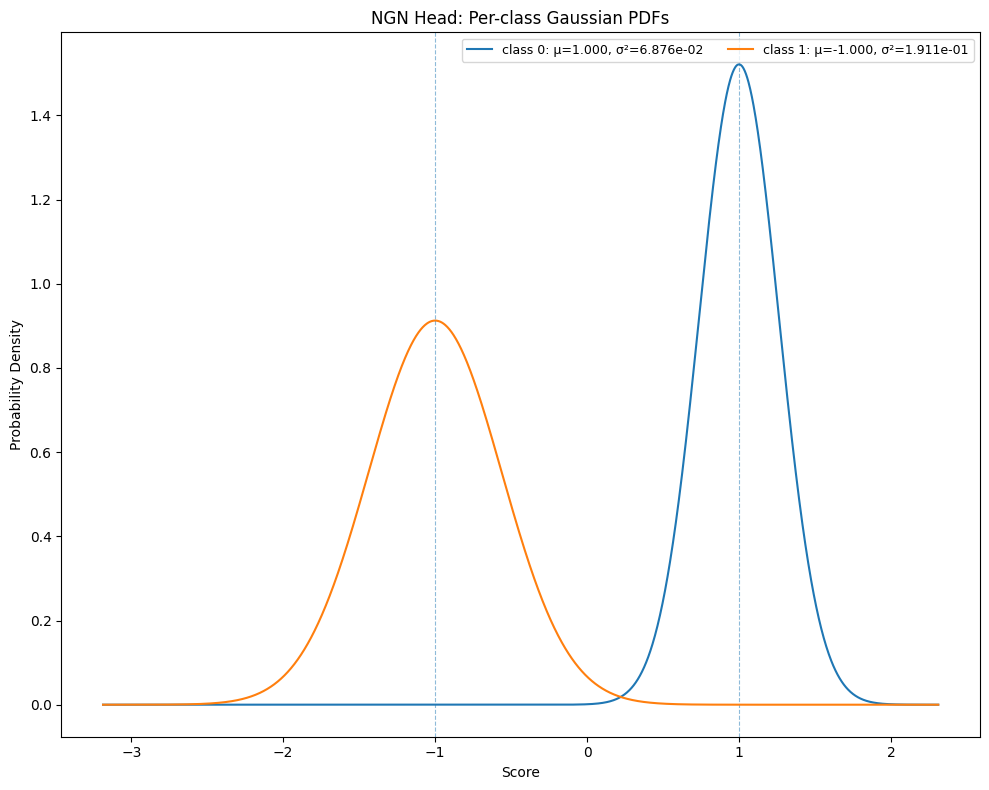

In [9]:
# Recompute current head stats (or reuse mu_out, S_out from training loop)
with torch.no_grad():
    mu_plot, S_plot = ngn_forward_stats(class_mean, class_cov)  # [C,1], [C,1,1] or [C,1]

# Extract means/variances as numpy
mu = mu_plot[:, 0].detach().cpu().numpy()  # shape [C]
if S_plot.dim() == 3:   # full covariance case
    var = S_plot[:, 0, 0].detach().cpu().numpy()
else:                   # diagonal covariance case
    var = S_plot[:, 0].detach().cpu().numpy()

# Safety clamp & std
eps = 1e-8
var = np.clip(var, eps, None)
std = np.sqrt(var)

# Global x-range covering all μ ± 5σ
x_min = float(np.min(mu - 5 * std))
x_max = float(np.max(mu + 5 * std))
if not np.isfinite(x_min) or not np.isfinite(x_max) or x_min == x_max:
    x_min, x_max = -5.0, 5.0
x = np.linspace(x_min, x_max, 2000)

# Plot
plt.figure(figsize=(10, 8))
for i in range(len(mu)):
    y = norm.pdf(x, mu[i], std[i])
    plt.plot(x, y, label=f'class {i}: μ={mu[i]:.3f}, σ²={var[i]:.3e}')
    plt.axvline(mu[i], linestyle='--', linewidth=0.8, alpha=0.5)

plt.title('NGN Head: Per-class Gaussian PDFs')
plt.xlabel('Score')
plt.ylabel('Probability Density')
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

Test head sample (first row): tensor([0.2523], grad_fn=<SelectBackward0>)
[TRAIN] neuron 0, class 0 | emp μ=1.000000, emp σ²=6.876050e-02 | analytic μ=1.000000, σ²=6.876048e-02
[TEST ] neuron 0, class 0 | emp μ=0.909447, emp σ²=2.948314e-01 | analytic μ=1.000000, σ²=6.876048e-02


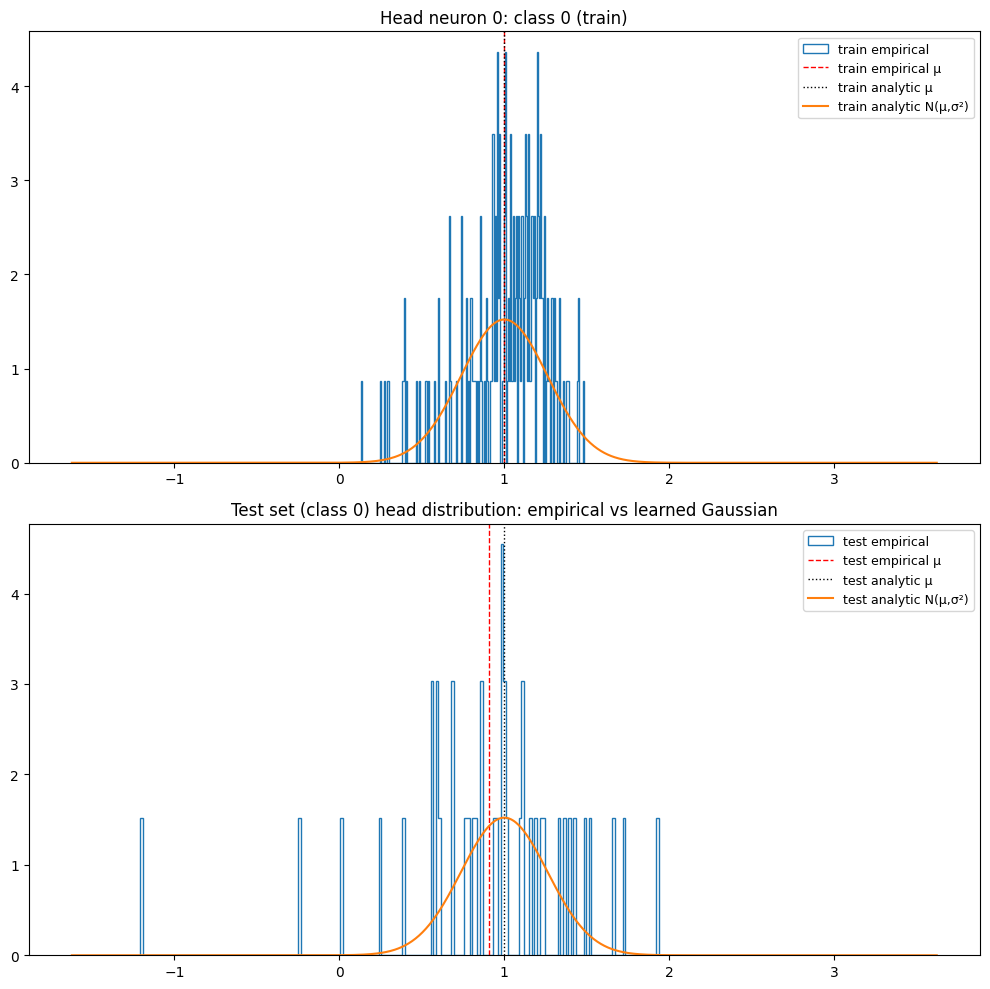

In [ ]:
# --- Build ReLU masks from the class-mean (sample/inference path) ---
# We compute masks once from the target class mean; these masks are then applied to test data.
masks = []
target_class = 0

class_zero_train = train_c[target_class]                 # [N0, D]
class_mean_vec   = class_zero_train.mean(0, keepdim=True)  # [1, D]

# Layer 0 → BN → mask_0
out = l0.inference(class_mean_vec)
out = b0.inference(out)
masks.append((out > 0).float())                          # [1, HIDDEN_0]
out = r0.inference(out)

# Layer 1 → BN → mask_1
out = l1.inference(out)
out = b1.inference(out)
masks.append((out > 0).float())                          # [1, HIDDEN_1]
out = r1.inference(out)
# (no mask after head)

# --- Apply masks to test data for inference (same gating pattern) ---
test_class = 0
class_zero_test = test_c[test_class]                     # [N_test, D]

test_out = l0.inference(class_zero_test)
test_out = b0.inference(test_out)
test_out = test_out * masks[0]                           # [N,H0] * [1,H0]
test_out = l1.inference(test_out)
test_out = b1.inference(test_out)
test_out = test_out * masks[1]                           # [N,H1] * [1,H1]
test_out = l2.inference(test_out)
test_out = b2.inference(test_out)                        # [N, 1]

# test_out = l0.inference(class_zero_test)
# test_out = b0.inference(test_out)
# test_out = r0.inference(test_out)                          # [N,H0] * [1,H0]
# test_out = l1.inference(test_out)
# test_out = b1.inference(test_out)
# test_out = r1.inference(test_out)                          # [N,H1] * [1,H1]
# test_out = l2.inference(test_out)
# test_out = b2.inference(test_out)                        # [N, 1]

print("Test head sample (first row):", test_out[0])

# --- Analytic stats for comparison (distribution path) ---
layer_mean, cov_matrix = ngn_forward_stats(class_mean, class_cov)  # [C,1], [C,1,1] or [C,1]

# --- Plot per-neuron (head is 1-D) ---
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

HEAD_DIM = layer_mean.shape[1]  # should be 1
fig, axes = plt.subplots(HEAD_DIM + 1, 1, figsize=(10, 10))
if HEAD_DIM == 1:
    axes = np.atleast_1d(axes)

for neuron in range(HEAD_DIM):
    # ===== TRAIN (empirical) vs ANALYTIC for class j=0 on the head =====
    j = 0
    calculated_mean_all = layer_mean[:, neuron].detach().cpu().numpy()    # [C]
    if cov_matrix.dim() == 3:
        calculated_var_j = cov_matrix[j, neuron, neuron].detach().cpu().numpy().item()
    else:
        calculated_var_j = cov_matrix[j, neuron].detach().cpu().numpy().item()

    # Empirical (train set, passed through inference path)
    out = l0.inference(class_zero_train)
    out = b0.inference(out); out = r0.inference(out)
    out = l1.inference(out)
    out = b1.inference(out); out = r1.inference(out)
    out = l2.inference(out); out = b2.inference(out)                      # [N0, 1]

    neuron_vals = out[:, neuron].detach().cpu().numpy()
    neuron_mean = float(np.mean(neuron_vals))
    neuron_var  = float(np.var(neuron_vals, ddof=0))

    mean_train_analytic = float(calculated_mean_all[j])
    var_train_analytic  = float(max(calculated_var_j, 1e-8))
    std_train_analytic  = np.sqrt(var_train_analytic)

    print(f"[TRAIN] neuron {neuron}, class {j} | "
          f"emp μ={neuron_mean:.6f}, emp σ²={neuron_var:.6e} | "
          f"analytic μ={mean_train_analytic:.6f}, σ²={var_train_analytic:.6e}")

    # Train histogram + analytic curve
    counts, bins, _ = axes[neuron].hist(neuron_vals, bins=200, histtype='step',
                                        density=True, label='train empirical')
    axes[neuron].axvline(neuron_mean, color='r', linestyle='--', linewidth=1.0, label='train empirical μ')
    axes[neuron].axvline(mean_train_analytic, color='k', linestyle=':',  linewidth=1.0, label='train analytic μ')

    x_values = np.linspace(mean_train_analytic - 10 * std_train_analytic,
                           mean_train_analytic + 10 * std_train_analytic, 1000)
    axes[neuron].plot(x_values, norm.pdf(x_values, mean_train_analytic, std_train_analytic),
                      label='train analytic N(μ,σ²)')

    axes[neuron].set_title(f'Head neuron {neuron}: class {j} (train)')
    axes[neuron].legend(loc='best', fontsize=9)

# ===== TEST (empirical) vs ANALYTIC for class test_class on the head =====
neuron = 0  # head only
test_vals = test_out[:, neuron].detach().cpu().numpy()

# Analytic stats for the test class from learned distributions
if cov_matrix.dim() == 3:
    var_test_analytic = cov_matrix[test_class, neuron, neuron].detach().cpu().numpy().item()
else:
    var_test_analytic = cov_matrix[test_class, neuron].detach().cpu().numpy().item()
mean_test_analytic = float(layer_mean[test_class, neuron].detach().cpu().numpy().item())
var_test_analytic  = float(max(var_test_analytic, 1e-8))
std_test_analytic  = np.sqrt(var_test_analytic)

# Empirical stats on test
test_emp_mu  = float(np.mean(test_vals))
test_emp_var = float(np.var(test_vals, ddof=0))

print(f"[TEST ] neuron {neuron}, class {test_class} | "
      f"emp μ={test_emp_mu:.6f}, emp σ²={test_emp_var:.6e} | "
      f"analytic μ={mean_test_analytic:.6f}, σ²={var_test_analytic:.6e}")

ax = axes[HEAD_DIM]
ax.hist(test_vals, bins=200, histtype='step', density=True, label='test empirical')
ax.axvline(test_emp_mu,        color='r', linestyle='--', linewidth=1.0, label='test empirical μ')
ax.axvline(mean_test_analytic, color='k', linestyle=':',  linewidth=1.0, label='test analytic μ')

x_test = np.linspace(mean_test_analytic - 10 * std_test_analytic,
                     mean_test_analytic + 10 * std_test_analytic, 1000)
ax.plot(x_test, norm.pdf(x_test, mean_test_analytic, std_test_analytic),
        label='test analytic N(μ,σ²)')

ax.set_title(f'Test set (class {test_class}) head distribution: empirical vs learned Gaussian')
ax.legend(loc='best', fontsize=9)

plt.tight_layout()
plt.show()


[Empirical class 3 (own masks)] μ=-0.100273, σ²=1.447548e-01
[Analytic  class 3]           μ=-0.049133, σ²=1.451150e-01
[Reference analytic target=0]             μ=2.766960, σ²=1.493628e-01


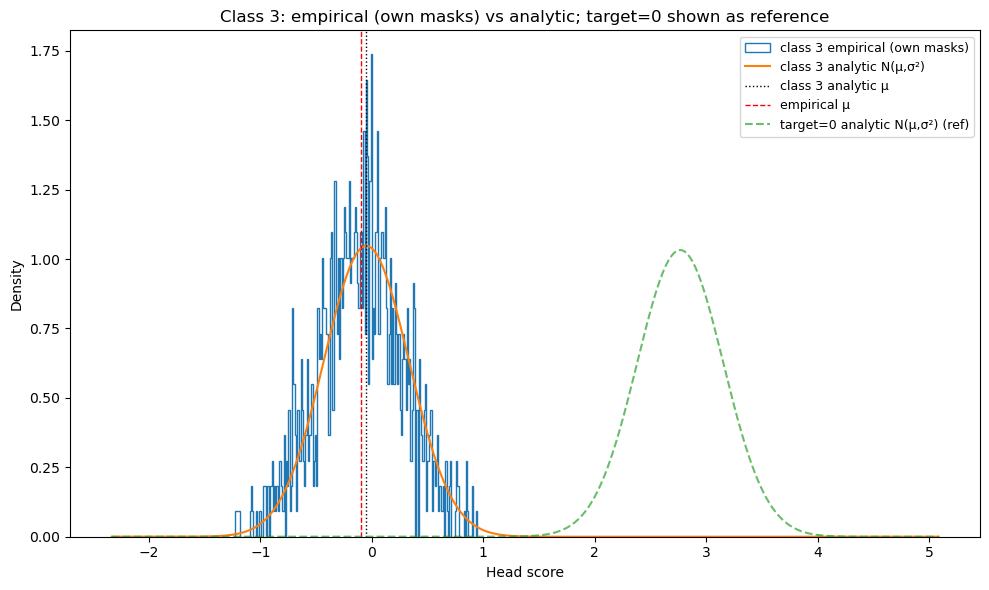

In [76]:
# --- Build OWN masks for other_class from its train mean (inference path) ---
other_class = 3  # keep this visible

# 1) Build masks from class-3 train mean
cls_train = train_c[other_class]                           # [N_train, D]
cls_mean  = cls_train.mean(0, keepdim=True)                # [1, D]

o = l0.inference(cls_mean); o = b0.inference(o)
m0_own = (o > 0).float(); o = r0.inference(o)
o = l1.inference(o);       o = b1.inference(o)
m1_own = (o > 0).float();  o = r1.inference(o)
masks_own = [m0_own, m1_own]

# 2) Push class-3 TEST data through its OWN masks
cls_test = test_c[other_class]                              # [N_test, D]
out = l0.inference(cls_test); out = b0.inference(out); out = out * masks_own[0]
out = l1.inference(out);  out = b1.inference(out);  out = out * masks_own[1]
out = l2.inference(out);  out = b2.inference(out)           # [N_test, 1]

emp_vals = out[:, 0].detach().cpu().numpy()
emp_mu   = float(emp_vals.mean())
emp_var  = float(emp_vals.var(ddof=0))

# 3) Analytic head stats (class-3 for match, class-0 for reference)
with torch.no_grad():
    mu_all, S_all = ngn_forward_stats(class_mean, class_cov)   # [C,1], [C,1,1] or [C,1]

def _mu_var(cls_idx):
    mu = float(mu_all[cls_idx, 0].detach().cpu().numpy().item())
    if S_all.dim() == 3:
        var = float(S_all[cls_idx, 0, 0].detach().cpu().numpy().item())
    else:
        var = float(S_all[cls_idx, 0].detach().cpu().numpy().item())
    return mu, max(var, 1e-8)

mu_other, var_other = _mu_var(other_class)   # should align with emp_vals
mu_target, var_target = _mu_var(0)           # just for reference (target=0)

print(f"[Empirical class {other_class} (own masks)] μ={emp_mu:.6f}, σ²={emp_var:.6e}")
print(f"[Analytic  class {other_class}]           μ={mu_other:.6f}, σ²={var_other:.6e}")
print(f"[Reference analytic target=0]             μ={mu_target:.6f}, σ²={var_target:.6e}")

# 4) Plot: class-3 empirical (own masks) vs class-3 analytic; dashed curve for class-0 analytic (ref)
import numpy as np, matplotlib.pyplot as plt
from scipy.stats import norm

sigma_other  = np.sqrt(var_other)
sigma_target = np.sqrt(var_target)

x_min = min(emp_vals.min(), mu_other - 6*sigma_other, mu_target - 6*sigma_target)
x_max = max(emp_vals.max(), mu_other + 6*sigma_other, mu_target + 6*sigma_target)
x = np.linspace(x_min, x_max, 2000)

plt.figure(figsize=(10, 6))
# Empirical histogram (class-3 under OWN masks)
plt.hist(emp_vals, bins=200, density=True, histtype='step', label=f'class {other_class} empirical (own masks)')

# Analytic (match): class-3
plt.plot(x, norm.pdf(x, mu_other, sigma_other), label=f'class {other_class} analytic N(μ,σ²)')
plt.axvline(mu_other, color='k', linestyle=':', linewidth=1.0, label=f'class {other_class} analytic μ')
plt.axvline(emp_mu,   color='r', linestyle='--', linewidth=1.0, label='empirical μ')

# Analytic (reference): class-0 (dashed)
plt.plot(x, norm.pdf(x, mu_target, sigma_target), linestyle='--', alpha=0.7,
         label='target=0 analytic N(μ,σ²) (ref)')

plt.title(f'Class {other_class}: empirical (own masks) vs analytic; target=0 shown as reference')
plt.xlabel('Head score'); plt.ylabel('Density')
plt.legend(fontsize=9); plt.tight_layout(); plt.show()


In [108]:
# ============================================================
# One-vs-Rest (TARGET = 0) single-sample inference — FULL CODE
#  - Uses TARGET-only masks (built from class-0 train mean)
#  - Proper impostor aggregation (logsumexp / sum / max)
#  - Correct σ-margin decision: ACCEPT if
#       y ≥ (μ0 - mσ0)  AND  y ≥ max_j (μj + mσj)
#  - Includes demo: runs on one class-0 sample and one non-0 sample
#  - Assumes you already defined:
#       train_c, class_mean, class_cov, ngn_forward_stats,
#       and NGN layers: l0,b0,r0,l1,b1,r1,l2,b2
#    If test_c/test_data aren’t present, it will load MNIST test set.
# ============================================================

import numpy as np
import torch
from scipy.stats import norm
from scipy.special import logsumexp

# ------------- Config -------------
OVR_TARGET = 0
NUM_CLASSES = 10
EPS = 1e-8

# ------------- Data helpers (robust to missing globals) -------------
def _ensure_test_sources():
    """Prefer per-class tensors (test_c). Fallback to loading MNIST test set."""
    if 'test_c' in globals() and isinstance(test_c, (list, tuple)) and len(test_c) == NUM_CLASSES:
        return 'per_class'
    # Fallback: load MNIST test set if needed
    if 'test_data' not in globals():
        from torchvision import datasets, transforms
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.1307,), (0.3081,))
        ])
        globals()['test_data'] = datasets.MNIST(root='data', train=False, download=True, transform=transform)
    return 'dataset'

def get_test_sample_by_label(label_id: int):
    """Return a single sample shaped [1, D] with the requested label."""
    mode = _ensure_test_sources()
    if mode == 'per_class':
        X = test_c[label_id]
        if X.ndim == 2:        # [N, D] flattened
            return X[0:1, :]   # [1, D]
        elif X.ndim == 4:      # [N, C, H, W]
            return X[0:1].view(1, -1)
        else:
            return X[0:1].view(1, -1)
    else:
        for img, lbl in test_data:
            if int(lbl) == int(label_id):
                return img.view(1, -1)
        raise ValueError(f"No test sample found for label {label_id}")

# ------------- TARGET masks (from class-0 train mean) -------------
def get_target_masks_from_train_mean(target=OVR_TARGET):
    """
    Build mean-mask ReLU gates for TARGET using its TRAIN mean via the inference path.
    Requires: train_c and NGN layers l0,b0,r0,l1,b1,r1.
    Returns [mask0, mask1].
    """
    if 'train_c' not in globals():
        raise RuntimeError("train_c is required to build target masks (class-mean).")
    vec = train_c[target].mean(0, keepdim=True)  # [1, D]
    o = l0.inference(vec); o = b0.inference(o); m0 = (o > 0).float(); o = r0.inference(o)
    o = l1.inference(o);  o = b1.inference(o);  m1 = (o > 0).float(); o = r1.inference(o)
    return [m0, m1]

def apply_target_masks_inference(x, target_masks):
    """
    Push a batch x [N,D] through the TARGET-masked NGN inference path.
    Requires: l0,b0,r0,l1,b1,r1,l2,b2 defined.
    Returns head outputs [N,1].
    """
    o = l0.inference(x); o = b0.inference(o); o = o * target_masks[0]
    o = l1.inference(o); o = b1.inference(o); o = o * target_masks[1]
    o = l2.inference(o); o = b2.inference(o)
    return o

# ------------- OVR inference (TARGET=0) -------------
def ovr_single_inference(
    x_single: torch.Tensor,
    class_mean: torch.Tensor, class_cov: torch.Tensor,
    target_masks,
    agg: str = 'logsumexp',          # 'logsumexp' (stable sum), 'sum', or 'max'
    prior_target: float = 0.5, prior_others: float = 0.5,
    margin_m: float = 3.0,
    min_sigma: float = 1e-4,
    eps: float = EPS
):
    """
    One-vs-Rest decision for TARGET CLASS 0.
      1) y = NGN(x) under TARGET masks only
      2) p0 = N(y; μ0, σ0^2); impostors = {N(y; μj, σj^2) for j≠0}
      3) Aggregate impostors properly (pdf units): logsumexp/sum/max
      4) P0 = (π0 p0) / (π0 p0 + π¬0 p_imp)
      5) σ-margin: ACCEPT if y ≥ (μ0 - mσ0) AND y ≥ max_j (μj + mσj)
    Returns dict with fields: y, P0, target{μ0,σ0,p0,z0}, impostor{p_imp,nearest}, margin{...}
    """
    # 1) Scalar head score under TARGET masks
    o = apply_target_masks_inference(x_single, target_masks)
    y = float(o[0, 0].detach().cpu().numpy())

    # helper to read μ, σ for class k
    def _mu_sig(k):
        mu_k = float(class_mean[k, 0].detach().cpu().numpy())
        if class_cov.dim() == 3:
            var_k = float(class_cov[k, 0, 0].detach().cpu().numpy())
        else:
            var_k = float(class_cov[k, 0].detach().cpu().numpy())
        sig_k = max(np.sqrt(max(var_k, eps)), min_sigma)
        return mu_k, sig_k

    # TARGET likelihood
    mu0, sig0 = _mu_sig(OVR_TARGET)
    p0 = float(norm.pdf(y, mu0, sig0))
    z0 = (y - mu0) / sig0

    # impostor likelihoods
    impostor, loglikes = [], []
    C = class_mean.shape[0]
    for j in range(C):
        if j == OVR_TARGET: 
            continue
        muj, sigj = _mu_sig(j)
        pj = float(norm.pdf(y, muj, sigj))
        zj = (y - muj) / sigj
        impostor.append({'cls': j, 'mu': muj, 'sigma': sigj, 'p': pj, 'z': zj})
        loglikes.append(np.log(pj + 1e-300))  # robust floor

    # 2) Aggregate impostors in pdf units
    if agg == 'max':
        p_imp = max(s['p'] for s in impostor)
        agg_desc = 'max'
    elif agg == 'sum':
        p_imp = sum(s['p'] for s in impostor)
        agg_desc = 'sum'
    else:  # 'logsumexp'
        p_imp = float(np.exp(logsumexp(loglikes)))
        agg_desc = 'logsumexp'

    # 3) Posterior-like probability for TARGET CLASS 0
    prior_target = float(prior_target); prior_others = float(prior_others)
    denom = prior_target * p0 + prior_others * p_imp
    P0 = (prior_target * p0) / max(denom, 1e-300)

    # 4) σ-margin (correct logic): ACCEPT if y ≥ (μ0 - mσ0) AND y ≥ max_j (μj + mσj)
    target_lower = mu0 - margin_m * sig0
    impostor_upper_bounds = [s['mu'] + margin_m * s['sigma'] for s in impostor]
    worst_impostor_upper = float(np.max(impostor_upper_bounds)) if impostor_upper_bounds else -np.inf
    margin_pass = (y >= target_lower) and (y >= worst_impostor_upper)

    # nearest impostor (by likelihood at y)
    nearest = max(impostor, key=lambda s: s['p'])

    return {
        'y': y,
        'P0': P0,
        'agg': agg_desc,
        'target':   {'cls': OVR_TARGET, 'mu': mu0, 'sigma': sig0, 'p': p0, 'z': z0},
        'impostor': {'p_imp': p_imp, 'nearest': nearest},
        'margin':   {
            'm': margin_m,
            'target_lower': target_lower,                   # μ0 - mσ0
            'worst_impostor_upper': worst_impostor_upper,   # max_j (μj + mσj)
            'pass': bool(margin_pass),
        },
    }

# ------------- Demo: compare class-0 vs non-0 -------------
# Build TARGET masks once (from train_c[0] mean)
target_masks = get_target_masks_from_train_mean(OVR_TARGET)

# Analytic stats from your NGN (uses your trained parameters)
with torch.no_grad():
    mu_all, S_all = ngn_forward_stats(class_mean, class_cov)

# Get a sample FROM class 0 and a sample FROM another class (e.g., 3)
x_class0 = get_test_sample_by_label(0)  # [1, D]
x_other  = get_test_sample_by_label(3)  # [1, D]

# Run OVR inference on both
res_class0 = ovr_single_inference(
    x_class0, mu_all, S_all, target_masks,
    agg='logsumexp', prior_target=0.5, prior_others=0.5, margin_m=3.0
)
res_other = ovr_single_inference(
    x_other,  mu_all, S_all, target_masks,
    agg='logsumexp', prior_target=0.5, prior_others=0.5, margin_m=3.0
)

# ------------- Pretty print -------------
def _print(res, tag):
    print("====================================================")
    print(f"[{tag}] Head score y = {res['y']:.6f}")
    t = res['target']
    print(f"[TARGET CLASS 0] μ₀={t['mu']:.6f}, σ₀={t['sigma']:.6f}, z₀={t['z']:+.2f}, p₀={t['p']:.3e}")
    ni = res['impostor']['nearest']
    print(f"[Impostors agg={res['agg']}] p_imp={res['impostor']['p_imp']:.3e} | "
          f"nearest class={ni['cls']} (μ={ni['mu']:.6f}, σ={ni['sigma']:.6f}, z={ni['z']:+.2f}, p={ni['p']:.3e})")
    print(f"[Posterior-like] P(class=0 | y) ≈ {res['P0']:.4f}")
    m = res['margin']
    print(f"[σ-margin m={m['m']}] "
          f"y ≥ (μ0 - mσ0) = {m['target_lower']:.6f}  AND  "
          f"y ≥ max_j(μj + mσj) = {m['worst_impostor_upper']:.6f}  "
          f"=> {'PASS ✅' if m['pass'] else 'FAIL ❌'}")
    print("====================================================")

_print(res_class0, "Sample FROM class 0 (target)")
_print(res_other,  "Sample FROM other class (impostor)")



[Sample FROM class 0 (target)] Head score y = 2.813675
[TARGET CLASS 0] μ₀=2.766960, σ₀=0.386475, z₀=+0.12, p₀=1.025e+00
[Impostors agg=logsumexp] p_imp=3.226e-09 | nearest class=9 (μ=-0.617240, σ=0.549677, z=+6.24, p=2.518e-09)
[Posterior-like] P(class=0 | y) ≈ 1.0000
[σ-margin m=3.0] y ≥ (μ0 - mσ0) = 1.607536  AND  y ≥ max_j(μj + mσj) = 1.239884  => PASS ✅
[Sample FROM other class (impostor)] Head score y = -0.087037
[TARGET CLASS 0] μ₀=2.766960, σ₀=0.386475, z₀=-7.38, p₀=1.486e-12
[Impostors agg=logsumexp] p_imp=5.611e+00 | nearest class=3 (μ=-0.049133, σ=0.380940, z=-0.10, p=1.042e+00)
[Posterior-like] P(class=0 | y) ≈ 0.0000
[σ-margin m=3.0] y ≥ (μ0 - mσ0) = 1.607536  AND  y ≥ max_j(μj + mσj) = 1.239884  => FAIL ❌


# all drafts below

## Concerns
* Lack of epistemic uncertainty modelling
* OOD detection is questionable
* Loss of data efficiency, since we use batch statistics instead of per-sample statistics